In [3]:
!pip install numpy pandas scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("/final_trendingtopics_reddit.csv")
embeddings = np.load("/sentence_embeddings.npy")

print("Data shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

Data shape: (7090, 13)
Embeddings shape: (7090, 384)


In [7]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=10,
    metric="cosine",
    linkage="average"
)

labels = model.fit_predict(embeddings)
df["cluster"] = labels

print("Number of clusters:", len(set(labels)))

Number of clusters: 10


In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, labels, metric="cosine")
print("Silhouette Score:", score)


Silhouette Score: 0.044214506


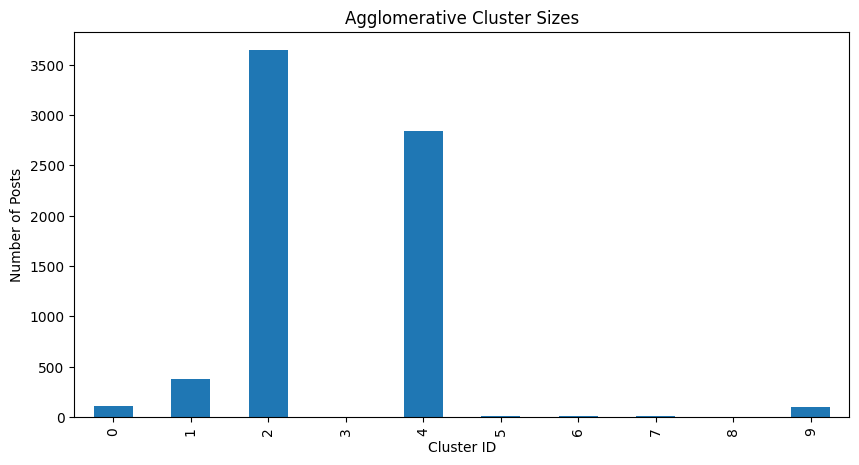

In [9]:
import matplotlib.pyplot as plt

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(10,5))
cluster_counts.plot(kind="bar")
plt.title("Agglomerative Cluster Sizes")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Posts")
plt.show()

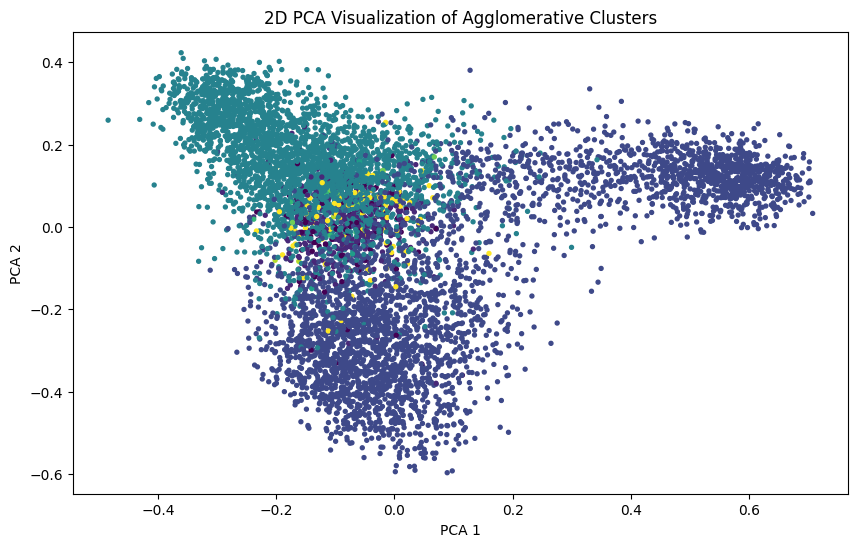

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10,6))
plt.scatter(points_2d[:,0], points_2d[:,1], c=df["cluster"], s=8)
plt.title("2D PCA Visualization of Agglomerative Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Cluster Size Distribution Analysis

This bar chart shows the number of Reddit posts assigned to each agglomerative cluster.

Observations:

- The distribution is highly imbalanced.
- Cluster 2 contains the largest number of posts (~3600).
- Cluster 4 is also significantly large (~2800).
- Most other clusters contain very few posts.

Interpretation:

This imbalance suggests that the model is grouping a large portion of the dataset into a few broad clusters, rather than forming evenly distributed and meaningful topic groups.

Such behavior indicates that agglomerative clustering is not effectively capturing fine-grained topic structure in the data.


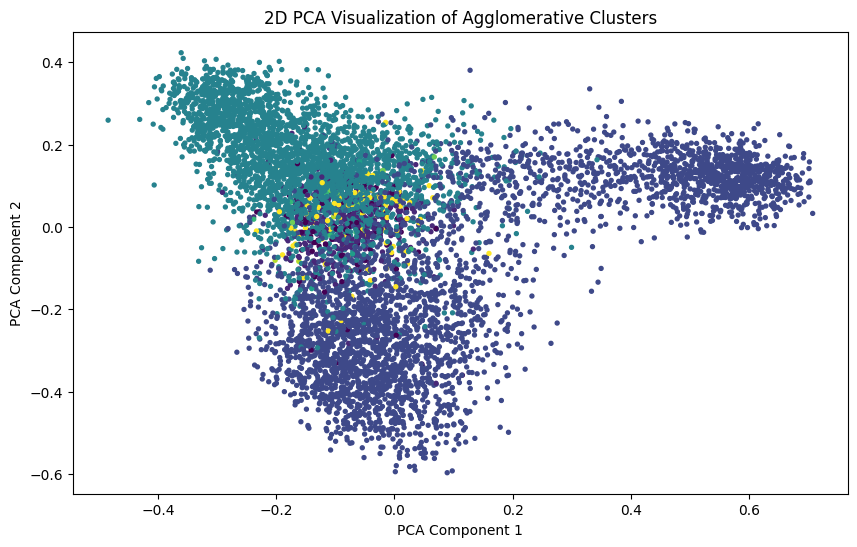

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10,6))
plt.scatter(points_2d[:, 0], points_2d[:, 1], c=df["cluster"], s=8)
plt.title("2D PCA Visualization of Agglomerative Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## PCA Visualization of Clusters

This plot shows a 2D projection of the high-dimensional sentence embeddings using Principal Component Analysis (PCA).

Each point represents a Reddit post, and the color indicates its assigned cluster.

Observations:

- Significant overlap exists between clusters.
- There are no clear boundaries separating different clusters.
- Some dense regions appear, but they are not distinctly partitioned.

Interpretation:

The lack of clear separation between clusters visually confirms the low silhouette score (~0.04).  
This indicates that many data points are not well matched to their assigned clusters and that cluster boundaries are weak.

Overall, the visualization suggests poor clustering quality and weak topic separation.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# make sure text column is clean
df["text_clean"] = df["text_translated"].fillna("").astype(str)

# get unique clusters
clusters = sorted(df["cluster"].unique())

for cluster_id in clusters:
    print("\n======================")
    print(f"Cluster {cluster_id} Top Keywords")
    print("======================")

    texts = df[df["cluster"] == cluster_id]["text_clean"]

    # skip tiny clusters
    if len(texts) < 5:
        print("Too few samples")
        continue

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=20
    )

    X = vectorizer.fit_transform(texts)

    words = vectorizer.get_feature_names_out()
    scores = X.mean(axis=0).A1

    top_words = sorted(zip(words, scores), key=lambda x: x[1], reverse=True)[:10]

    print([word for word, score in top_words])


Cluster 0 Top Keywords
['new', 'study', 'years', 'scientists', 'species', 'like', 'human', 'animals', 'sperm', 'giant']

Cluster 1 Top Keywords
['study', 'brain', 'people', 'new', 'risk', 'health', 'cancer', 'linked', 'associated', 'researchers']

Cluster 2 Top Keywords
['phone', 'movie', 'like', 'just', 'game', 'new', 'movies', 'good', 'games', 'film']

Cluster 3 Top Keywords
Too few samples

Cluster 4 Top Keywords
['ai', 'iran', 'says', 'new', 'trump', 'war', 'ukraine', 'china', 'data', 'russian']

Cluster 5 Top Keywords
Too few samples

Cluster 6 Top Keywords
['mercury', 'statue', 'sword', 'remains', 'archaeology', 'church', 'era', 'family', 'idea', 'weapons']

Cluster 7 Top Keywords
['password', 'manager', 'secure', 'number', 'pin', 'passkeys', '10', '6bseswe4', 'passwords', 'people']

Cluster 8 Top Keywords
Too few samples

Cluster 9 Top Keywords
['new', 'moon', 'artemis', 'nasa', 'scientists', 'years', 'ii', 'space', 'researchers', 'light']


## Keyword Analysis per Cluster

The top TF-IDF keywords provide insight into the dominant themes within each cluster.

Observations:

- Some clusters show clear topic patterns (e.g., gaming, politics, science)
- Other clusters contain mixed or unrelated keywords
- Smaller clusters often lack meaningful keyword structure

This indicates that while agglomerative clustering can capture some topical similarity, it does not consistently produce clean and well-defined topic groups.

This further supports the earlier findings of low silhouette score and overlapping clusters.


# Final Observations and Conclusion

## Overall Findings

The agglomerative clustering approach produced the following results:

- Highly imbalanced cluster sizes
- Very low silhouette score (~0.04)
- Significant overlap between clusters in PCA visualization
- Inconsistent and mixed topic groupings

---

## Key Limitations of Agglomerative Clustering

- Requires a fixed number of clusters (n_clusters=10)
- Forces all data points into clusters (no noise handling)
- Struggles with high-dimensional semantic embeddings
- Produces large, broad clusters instead of well-defined topics

---

## Conclusion

Agglomerative clustering is not well-suited for this Reddit dataset.

The results show that:
- Clusters are not well-separated
- Topic grouping is weak and inconsistent

This justifies the use of **HDBSCAN** in the main project pipeline, as it:
- Automatically determines the number of clusters
- Handles noise effectively
- Produces more coherent and meaningful topic groupings


# Agglomerative Clustering Analysis on Reddit Data

This notebook applies hierarchical (agglomerative) clustering on Reddit posts using sentence embeddings to analyze topic grouping quality.